In [1]:
import torch
import models as m
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [2]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

def t(x):
    return torch.as_tensor(x, dtype=torch.get_default_dtype(), device=device)

Using device: cuda:0


In [3]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")

EXP_NAME = "baseline"   
RUN_ID = "001"                  

EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR = os.path.join(RUN_DIR, "logs")
SAMPLES_DIR = os.path.join(RUN_DIR, "samples_pc")
os.makedirs(SAMPLES_DIR, exist_ok=True)

with open(os.path.join(LOGS_DIR, "hparams.json"), "r") as f:
    hparams = json.load(f)

print("Loaded hparams from:", RUN_DIR)
print("sigma hyperparams:", hparams["sigma"])
print("img_size:", hparams["img_size"])

sigma_min = hparams["sigma"]["min"]
sigma_max = hparams["sigma"]["max"]

img_size = hparams["img_size"]
C = hparams["model"]["in_channel"]
H = W = img_size

Loaded hparams from: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/baseline/001
sigma hyperparams: {'min': 0.01, 'max': 1.5}
img_size: 100


In [4]:
state_dict = torch.load(
    os.path.join(WEIGHTS_DIR, "model.pt"),
    map_location=device,
    weights_only=True,
)

model = m.SmallUNetSigma(
    in_ch=hparams["model"]["in_channel"],
    base_ch=hparams["model"]["base_ch"],
    channel_mults=hparams["model"]["channel_mults"],
    emb_dim=hparams["model"]["sigma_emb_dim"],
).to(device)

model.load_state_dict(state_dict)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model has {total_params/1e6:.2f}M parameters")

Model has 47.26M parameters


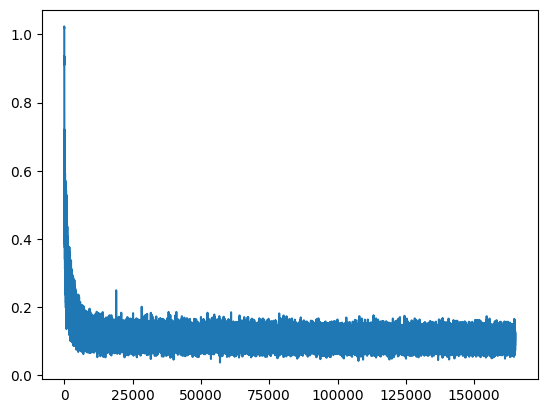

In [6]:
Loss = np.load(os.path.join(LOGS_DIR,'train_loss.npy'))
steps_eval = np.load(os.path.join(LOGS_DIR,'steps_eval.npy'))
plt.plot(Loss)
plt.show()


In [5]:
# VE schedule σ(t) and g(t)
# Training: log σ(t) = log σ_min + t (log σ_max - log σ_min), t ∈ [0,1]

log_sigma_min = t(sigma_min).log()
log_sigma_max = t(sigma_max).log()
log_r = log_sigma_max - log_sigma_min   # log(σ_max / σ_min)

def sigma_of_t(t_scalar):
    """
    t_scalar: scalaire ou tensor in [0,1]
    returns σ(t) avec même dtype/device.
    """
    return torch.exp(log_sigma_min + t_scalar * log_r)

def g_of_t(t_scalar):
    """
    g(t) = sqrt(d/dt σ^2(t))
         = sqrt(2 log(σ_max/σ_min)) * σ(t)
    car σ^2(t) = σ_min^2 * (σ_max/σ_min)^{2t}.
    """
    sigma_t = sigma_of_t(t_scalar)
    return torch.sqrt(2.0 * log_r) * sigma_t

# Sanity check
for val in [0.0, 0.5, 1.0]:
    s = sigma_of_t(t(val))
    g = g_of_t(t(val))
    print(f"t={val:.2f} -> sigma={s.item():.4f}, g={g.item():.4f}")

t=0.00 -> sigma=0.0100, g=0.0317
t=0.50 -> sigma=0.1225, g=0.3877
t=1.00 -> sigma=1.5000, g=4.7485


In [6]:
# Predictor: reverse VE SDE 
@torch.no_grad()
def predictor_step(x, t_k, t_prev):
    """
    Reverse VE SDE:
      dx = -g(t)^2 s_theta(x,t) dt + g(t) dW_t, t: 1 -> 0.

    Discrétisation t_k -> t_prev < t_k:
      x_{k-1} = x_k
        - g(t_k)^2 s_theta(x_k,t_k) * |Δt|
        + g(t_k) sqrt(|Δt|) z_k,
      avec Δt = t_prev - t_k < 0.
    """
    
    dt = t_prev - t_k  # négatif
    assert (dt <= 0).all()

    sigma_k = sigma_of_t(t_k)  
    g_k = g_of_t(t_k)         

    B = x.shape[0]
    sigma_batch = sigma_k.view(1, 1).expand(B, 1)  # (B,1)
    score = model(x, sigma_batch)                  # (B,C,H,W)

    noise = torch.randn_like(x)
    x = x + (-g_k**2 * score) * dt + g_k * torch.sqrt(-dt) * noise
    return x

In [7]:
# Corrector: simple Langevin at fixed t 
@torch.no_grad()
def corrector_step(x, t_k, n_steps, base_eps=1e-4):
    """
    Correcteur Langevin classique à temps fixé t_k :
      x^{(m+1)} = x^{(m)} + ε_k s_theta(x^{(m)}, t_k) + sqrt(2 ε_k) z^{(m)}

    ε_k = base_eps * σ(t_k)^2
    """
    
    if n_steps <= 0:
        return x

    sigma_k = sigma_of_t(t_k)
    eps_k = base_eps * sigma_k**2

    for _ in range(n_steps):
        B = x.shape[0]
        sigma_batch = sigma_k.view(1, 1).expand(B, 1)  # (B,1)
        score = model(x, sigma_batch)

        noise = torch.randn_like(x)
        x = x + eps_k * score + torch.sqrt(2.0 * eps_k) * noise

    return x

In [8]:
def minmax_renorm_to_minus1_1(x):
    """
    x: (B, C, H, W)
    Renormalise chaque image individuellement dans [-1,1]
    via (x - min) / (max - min) * 2 - 1
    où min/max sont pris sur (C,H,W) pour chaque image.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                  # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)

    # éviter la division par 0
    denom = (x_max - x_min).clamp_min(1e-8)

    x_scaled = (x - x_min) / denom          # dans [0,1]
    x_scaled = x_scaled * 2.0 - 1.0         # dans [-1,1]
    return x_scaled


# PC sampler
@torch.no_grad()
def pc_sampler_ve(num_samples=4,num_steps=1000,n_corrector_steps=1,corrector_base_eps=1e-4):
    """
    Sampler VE SDE avec Predictor–Corrector :
    - t_0 = 0 < ... < t_N = 1, on itère de N -> 0.
    - Predictor: Euler–Maruyama sur la reverse SDE.
    - Corrector: Langevin avec ε_k = base_eps * σ(t_k)^2.
    - Prior: x_T ~ N(0, σ_max^2 I).

    """

    # grille de temps
    t_grid = torch.linspace(0.0, 1.0, num_steps + 1, device=device)
    t_grid_rev = t_grid.flip(0)  # [1, ..., 0]

    # prior p_T = N(0, σ_max^2 I)
    x = torch.randn(num_samples, C, H, W, device=device) * sigma_max
    print(f"Init shape: {x.shape}, prior σ_max={sigma_max}")

    # indices de snapshots: début, 25%, 50%, 75%, fin
    snapshot_fracs = [0.0, 0.25, 0.5, 0.75, 1.0]
    snapshot_indices = sorted(
        {int(frac * num_steps) for frac in snapshot_fracs}
    )  # unique + trié
    print("Snapshot steps:", snapshot_indices)

    snapshots = {}  # step -> tensor (num_samples, C, H, W)

    # snapshot initial (avant toute update)
    snapshots[0] = x.clone()

    for i in range(num_steps):
        t_k = t_grid_rev[i]      # temps courant
        t_prev = t_grid_rev[i+1] # temps suivant (plus proche de 0)

        # predictor
        x = predictor_step(x, t_k, t_prev)

        # corrector
        x = corrector_step(x, t_k, n_corrector_steps, base_eps=corrector_base_eps)

        # sauvegarde snapshot si index match
        step_id = i + 1
        if step_id in snapshot_indices:
            snapshots[step_id] = x.clone()

        if (i + 1) % max(1, num_steps // 10) == 0:
            print(f"[{i+1}/{num_steps}] t={t_k.item():.4f}")

    x_renorm = minmax_renorm_to_minus1_1(x)

    # renorm aussi les snapshots (si tu veux les afficher ensuite)
    snapshots_renorm = {}
    for k, x_snap in snapshots.items():
        snapshots_renorm[k] = minmax_renorm_to_minus1_1(x_snap)

    return x_renorm, snapshots_renorm

 

In [9]:
def per_image_minmax_to_01(x):
    """
    x : (B, C, H, W)
    Pour chaque image du batch, fait :
        x -> (x - min) / (max - min)  dans [0,1]
    avec min/max pris sur (C,H,W) de chaque image séparément.
    """
    B = x.shape[0]
    x_flat = x.view(B, -1)                        # (B, C*H*W)
    x_min = x_flat.min(dim=1).values.view(B, 1, 1, 1)
    x_max = x_flat.max(dim=1).values.view(B, 1, 1, 1)
    denom = (x_max - x_min).clamp_min(1e-8)
    x_01 = (x - x_min) / denom
    return x_01


In [34]:
# Run sampler and visualize snapshots 
num_samples = 8
num_steps = 4000
n_corrector_steps = 2
corrector_base_eps = 1e-2


x_final, snapshots = pc_sampler_ve(
    num_samples=num_samples,
    num_steps=num_steps,
    n_corrector_steps=n_corrector_steps,
    corrector_base_eps=corrector_base_eps,
)


Init shape: torch.Size([8, 3, 100, 100]), prior σ_max=1.5
Snapshot steps: [0, 1000, 2000, 3000, 4000]
[400/4000] t=0.9003
[800/4000] t=0.8002
[1200/4000] t=0.7002
[1600/4000] t=0.6003
[2000/4000] t=0.5002
[2400/4000] t=0.4003
[2800/4000] t=0.3003
[3200/4000] t=0.2003
[3600/4000] t=0.1003
[4000/4000] t=0.0003


Saved snapshots figure to: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/baseline/001/samples_pc/snapshots_ve_pc_N2000_corr2_eps0.01.png


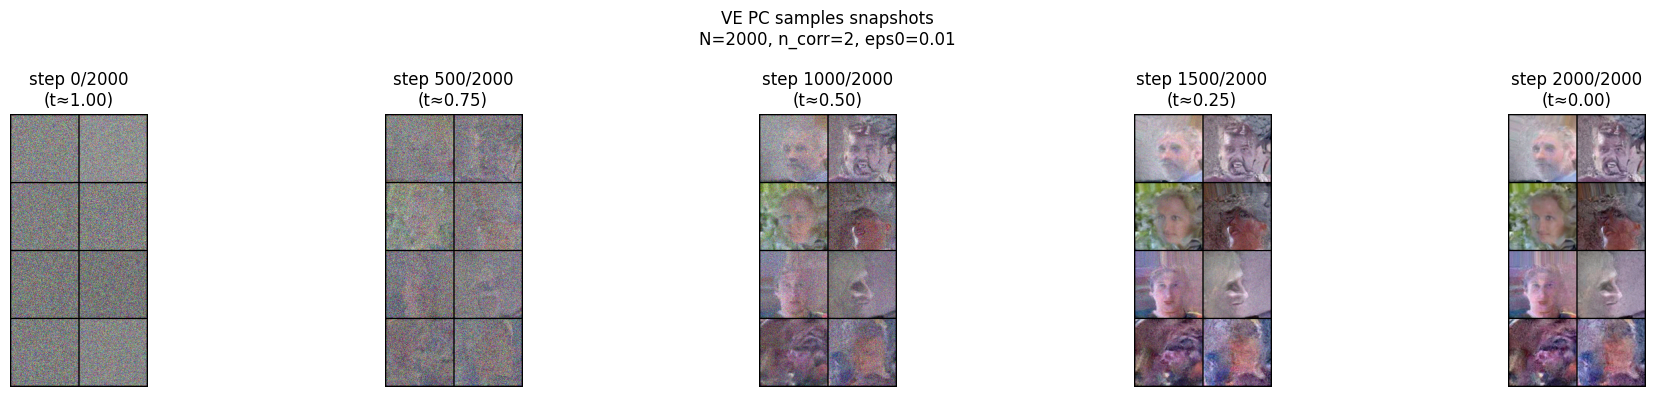

Saved final samples to: /home/infres/rplanchon-23/code/DSM/src/VE-SDE/celebA/runs/baseline/001/samples_pc/samples_ve_pc_final_N2000_corr2_eps0.01.png


In [33]:
# Renorm per-image pour affichage (dans [0,1])
x_final_vis = per_image_minmax_to_01(x_final)
snapshots_vis = {k: per_image_minmax_to_01(v) for k, v in snapshots.items()}

# On ordonne les snapshots par étape
sorted_steps = sorted(snapshots_vis.keys())

# Figure multi-snapshots : chaque colonne = un temps, lignes = images
n_cols = len(sorted_steps)
n_rows = 1  # on affiche un grid par snapshot

plt.figure(figsize=(4 * n_cols, 4))
for col, step_id in enumerate(sorted_steps):
    x_snap_vis = snapshots_vis[step_id]
    grid = make_grid(
        x_snap_vis,
        nrow=int(np.sqrt(num_samples))
    )
    plt.subplot(1, n_cols, col + 1)
    plt.imshow(grid.permute(1, 2, 0).detach().cpu().numpy())
    plt.axis("off")
    frac = step_id / num_steps
    plt.title(f"step {step_id}/{num_steps}\n(t≈{1-frac:.2f})")

plt.suptitle(
    f"VE PC samples snapshots\nN={num_steps}, n_corr={n_corrector_steps}, eps0={corrector_base_eps}"
)
# Sauvegarde de la figure snapshots
snap_save_path = os.path.join(
    SAMPLES_DIR,
    f"snapshots_ve_pc_N{num_steps}_corr{n_corrector_steps}_eps{corrector_base_eps}.png",
)
plt.savefig(snap_save_path, dpi=200, bbox_inches="tight")
print("Saved snapshots figure to:", snap_save_path)

plt.tight_layout()
plt.show()

# Et on sauvegarde aussi uniquement le grid final
final_grid = make_grid(x_final_vis, nrow=int(np.sqrt(num_samples)))
final_save_path = os.path.join(
    SAMPLES_DIR,
    f"samples_ve_pc_final_N{num_steps}_corr{n_corrector_steps}_eps{corrector_base_eps}.png",
)
plt.imsave(final_save_path, final_grid.permute(1, 2, 0).detach().cpu().numpy())
print("Saved final samples to:", final_save_path)
